#### Stochastic Simulation Project 2
Sophia Reiffenstein Petersen (s224222), Edvin Smajlovic (s224204) & Adam Bøttcher Haupt-Hansen (s224202) 

In [37]:
import numpy as np
import matplotlib.pyplot as plt
import scipy
import scipy.stats as stats
import random
from functions_project2 import *

#### Primary Task

In [38]:
np.random.seed(42)
total_beds = 75
Ward_A_LOS = lambda: np.random.lognormal(mean=np.log(4*np.sqrt(2)), sigma=np.sqrt(np.log(2)))
Ward_B_LOS = lambda: np.random.lognormal(mean=np.log(6*np.sqrt(2)), sigma=np.sqrt(np.log(2)))
Ward_C_LOS = lambda: np.random.lognormal(mean=np.log(5*np.sqrt(2)), sigma=np.sqrt(np.log(2)))

runs = 1000
blocking_probabilities_A = []
blocking_probabilities_B = []
blocking_probabilities_C = []

for _ in range(runs):
    results = simulate_patient_flow((20, 10), simulation_days=365, Ward_A_LOS=Ward_A_LOS, Ward_B_LOS=Ward_B_LOS, Ward_C_LOS=Ward_C_LOS, total_beds=total_beds)
    blocking_probabilities_A.append(results["blocking_probability"]["A"])
    blocking_probabilities_B.append(results["blocking_probability"]["B"])
    blocking_probabilities_C.append(results["blocking_probability"]["C"])

mean_A = np.mean(blocking_probabilities_A)
mean_B = np.mean(blocking_probabilities_B)
mean_C = np.mean(blocking_probabilities_C)

ci_A = conf_interval(blocking_probabilities_A)
ci_B = conf_interval(blocking_probabilities_B)
ci_C = conf_interval(blocking_probabilities_C)

print(f"Mean blocking probability for Ward A: {mean_A:.4f}, 95% CI: {ci_A}")
print(f"Mean blocking probability for Ward B: {mean_B:.4f}, 95% CI: {ci_B}")
print(f"Mean blocking probability for Ward C: {mean_C:.4f}, 95% CI: {ci_C}")

sum_relocated_A = []
sum_relocated_B = []
sum_relocated_C = []

for _ in range(runs):
    results = simulate_patient_flow((20, 10), simulation_days=365, Ward_A_LOS=Ward_A_LOS, Ward_B_LOS=Ward_B_LOS, Ward_C_LOS=Ward_C_LOS, total_beds=total_beds)
    sum_relocated_A.append(results["rejected"]["A"])
    sum_relocated_B.append(results["rejected"]["B"])
    sum_relocated_C.append(results["rejected"]["C"])

print(f"Mean number of patients rejected for Ward A: {np.mean(sum_relocated_A):.4f}")
print(f"Mean number of patients rejected for Ward B: {np.mean(sum_relocated_B):.4f}")
print(f"Mean number of patients rejected for Ward C: {np.mean(sum_relocated_C):.4f}")

print(f"Total mean number of patients rejected: {np.mean(sum_relocated_A) + np.mean(sum_relocated_B) + np.mean(sum_relocated_C):.4f}")

print(f"Percentage of patients rejected for Ward A: {np.mean(sum_relocated_A) / (np.mean(sum_relocated_A) + np.mean(sum_relocated_B) + np.mean(sum_relocated_C)) * 100:.2f}%")
print(f"Percentage of patients rejected for Ward B: {np.mean(sum_relocated_B) / (np.mean(sum_relocated_A) + np.mean(sum_relocated_B) + np.mean(sum_relocated_C)) * 100:.2f}%")
print(f"Percentage of patients rejected for Ward C: {np.mean(sum_relocated_C) / (np.mean(sum_relocated_A) + np.mean(sum_relocated_B) + np.mean(sum_relocated_C)) * 100:.2f}%")

Mean blocking probability for Ward A: 0.6460, 95% CI: (np.float64(0.6451785906907997), np.float64(0.646754683754663))
Mean blocking probability for Ward B: 0.4463, 95% CI: (np.float64(0.44416703761161636), np.float64(0.4484324635525043))
Mean blocking probability for Ward C: 0.2916, 95% CI: (np.float64(0.2902785534873555), np.float64(0.29282168244909806))
Mean number of patients rejected for Ward A: 1434.8340
Mean number of patients rejected for Ward B: 198.4710
Mean number of patients rejected for Ward C: 643.7230
Total mean number of patients rejected: 2277.0280
Percentage of patients rejected for Ward A: 63.01%
Percentage of patients rejected for Ward B: 8.72%
Percentage of patients rejected for Ward C: 28.27%


In [39]:
# Furthermore, estimate the mean fraction of beds that are utilized (occupied) in each ward.
# number of occupied bed / number of available beds in each ward. The number of available beds in each ward is given by the initial number of beds in each ward (20 for Ward A, 10 for Ward B, and 10 for Ward C) minus the number of patients that are rejected (relocated) from each ward.

Ward_A_utilization = []
Ward_B_utilization = []
Ward_C_utilization = []

for _ in range(runs):
    results = simulate_patient_flow((20, 10), simulation_days=365, Ward_A_LOS=Ward_A_LOS, Ward_B_LOS=Ward_B_LOS, Ward_C_LOS=Ward_C_LOS, total_beds=total_beds)
    Ward_A_utilization.append(results["Utilisation"]["A"])
    Ward_B_utilization.append(results["Utilisation"]["B"])
    Ward_C_utilization.append(results["Utilisation"]["C"])

print(f"Mean bed utilisation for Ward A: {np.mean(Ward_A_utilization):.4f}")
print(f"Mean bed utilisation for Ward B: {np.mean(Ward_B_utilization):.4f}")
print(f"Mean bed utilisation for Ward C: {np.mean(Ward_C_utilization):.4f}")

Mean bed utilisation for Ward A: 0.9165
Mean bed utilisation for Ward B: 0.8125
Mean bed utilisation for Ward C: 0.9653


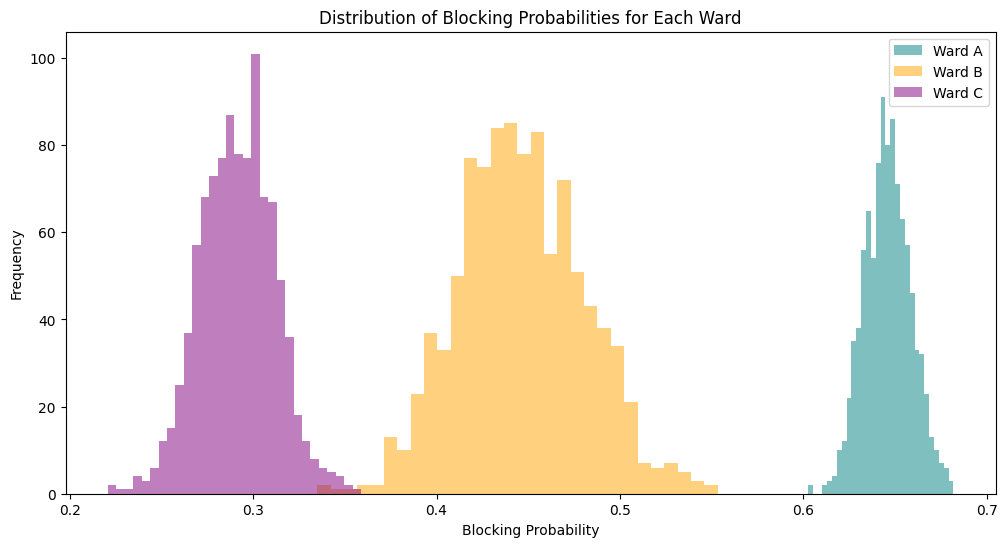

In [40]:
# visualize the distribution of blocking probabilities for each ward
plt.figure(figsize=(12, 6))
plt.hist(blocking_probabilities_A, bins=30, alpha=0.5, label='Ward A', color='teal')
plt.hist(blocking_probabilities_B, bins=30, alpha=0.5, label='Ward B', color='orange')
plt.hist(blocking_probabilities_C, bins=30, alpha=0.5, label='Ward C', color='purple')
plt.title('Distribution of Blocking Probabilities for Each Ward')
plt.xlabel('Blocking Probability')
plt.ylabel('Frequency')
plt.legend()
plt.show()

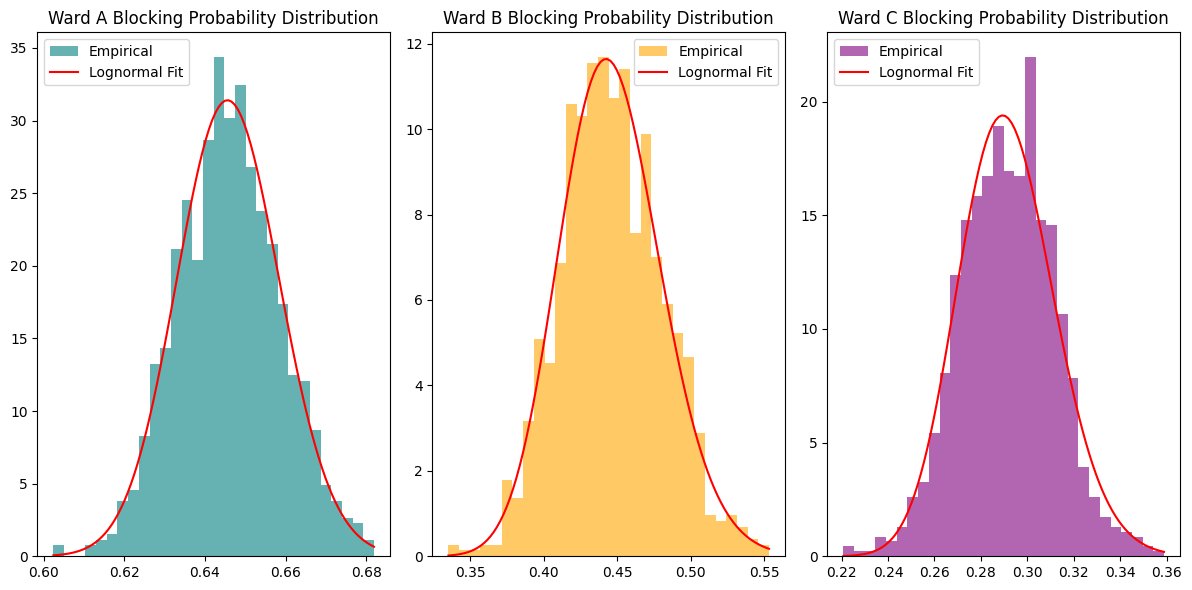

In [41]:
# Visualise Estimate the distribution of the blocking probabilities for each ward
# and compare to lognormal distribution 

probabilities = ['Ward A', 'Ward B', 'Ward C']

plt.figure(figsize=(12, 6))
plt.subplot(1, 3, 1)
plt.hist(blocking_probabilities_A, bins=30, density=True, alpha=0.6, color='teal', label='Empirical')
x = np.linspace(min(blocking_probabilities_A), max(blocking_probabilities_A), 100)
shape_A, loc_A, scale_A = stats.lognorm.fit(blocking_probabilities_A, floc=0)
pdf_A = stats.lognorm.pdf(x, shape_A, loc_A, scale_A)   
plt.plot(x, pdf_A, 'r-', label='Lognormal Fit')
plt.legend()
plt.title('Ward A Blocking Probability Distribution')

plt.subplot(1, 3, 2)
plt.hist(blocking_probabilities_B, bins=30, density=True, alpha=0.6, color='orange', label='Empirical')
x = np.linspace(min(blocking_probabilities_B), max(blocking_probabilities_B), 100)
shape_B, loc_B, scale_B = stats.lognorm.fit(blocking_probabilities_B, floc=0)
pdf_B = stats.lognorm.pdf(x, shape_B, loc_B, scale_B)
plt.plot(x, pdf_B, 'r-', label='Lognormal Fit')
plt.legend()
plt.title('Ward B Blocking Probability Distribution')

plt.subplot(1, 3, 3)
plt.hist(blocking_probabilities_C, bins=30, density=True, alpha=0.6, color='purple', label='Empirical')
x = np.linspace(min(blocking_probabilities_C), max(blocking_probabilities_C), 100)
shape_C, loc_C, scale_C = stats.lognorm.fit(blocking_probabilities_C, floc=0)
pdf_C = stats.lognorm.pdf(x, shape_C, loc_C, scale_C)
plt.plot(x, pdf_C, 'r-', label='Lognormal Fit')
plt.title('Ward C Blocking Probability Distribution')

plt.tight_layout()
plt.legend()
plt.show()

In [42]:
# ks test for goodness of fit
ks_stat_A, p_value_A = stats.kstest(blocking_probabilities_A, 'lognorm', args=(shape_A, loc_A, scale_A))
ks_stat_B, p_value_B = stats.kstest(blocking_probabilities_B, 'lognorm', args=(shape_B, loc_B, scale_B))
ks_stat_C, p_value_C = stats.kstest(blocking_probabilities_C, 'lognorm', args=(shape_C, loc_C, scale_C))

print(f"Ward A: KS Statistic = {ks_stat_A:.4f}, p-value = {p_value_A:.4f}")
print(f"Ward B: KS Statistic = {ks_stat_B:.4f}, p-value = {p_value_B:.4f}")
print(f"Ward C: KS Statistic = {ks_stat_C:.4f}, p-value = {p_value_C:.4f}")

Ward A: KS Statistic = 0.0155, p-value = 0.9672
Ward B: KS Statistic = 0.0195, p-value = 0.8319
Ward C: KS Statistic = 0.0338, p-value = 0.1978


#### Sensitivity Analysis

In [46]:
best_distribution, mean_rejections, results = \
    find_optimal_bed_distribution(
        total_beds=75,
        Ward_A_LOS=Ward_A_LOS,
        Ward_B_LOS=Ward_B_LOS,
        Ward_C_LOS=Ward_C_LOS,
        stage1_replications=5,
        stage2_replications=100,
        top_k=10
    )

print("\nBest distribution:")
print(best_distribution)

print("\nExpected rejections:")
print(mean_rejections)

print("\nDetailed results for the best distribution:")
print(results)

Finding optimal bed distribution...
Stage 1: Screening candidate allocations

Best distribution:
(15, 3, 57)

Expected rejections:
2263.52

Detailed results for the best distribution:
[{'beds_A': 15, 'beds_B': 3, 'beds_C': 57, 'mean_rejections': np.float64(2263.52), 'std_rejections': np.float64(79.09775054585397), 'mean_overflows': np.float64(9.97), 'mean_util_A': np.float64(0.937897716894977), 'mean_util_B': np.float64(0.9016803652968036), 'mean_util_C': np.float64(0.928510454217736)}, {'beds_A': 15, 'beds_B': 6, 'beds_C': 54, 'mean_rejections': np.float64(2271.76), 'std_rejections': np.float64(76.37283879135634), 'mean_overflows': np.float64(5.37), 'mean_util_A': np.float64(0.9345698630136985), 'mean_util_B': np.float64(0.8639132420091324), 'mean_util_C': np.float64(0.9406047691527142)}, {'beds_A': 15, 'beds_B': 5, 'beds_C': 55, 'mean_rejections': np.float64(2273.18), 'std_rejections': np.float64(70.98376254788518), 'mean_overflows': np.float64(7.28), 'mean_util_A': np.float64(0.9362

In [47]:
np.random.seed(42)

blocking_probabilities_A = []
blocking_probabilities_B = []
blocking_probabilities_C = []

for _ in range(runs):
    results = simulate_patient_flow((15, 3), simulation_days=365, Ward_A_LOS=Ward_A_LOS, Ward_B_LOS=Ward_B_LOS, Ward_C_LOS=Ward_C_LOS, total_beds=total_beds)
    blocking_probabilities_A.append(results["blocking_probability"]["A"])
    blocking_probabilities_B.append(results["blocking_probability"]["B"])
    blocking_probabilities_C.append(results["blocking_probability"]["C"])

mean_A = np.mean(blocking_probabilities_A)
mean_B = np.mean(blocking_probabilities_B)
mean_C = np.mean(blocking_probabilities_C)

ci_A = conf_interval(blocking_probabilities_A)
ci_B = conf_interval(blocking_probabilities_B)
ci_C = conf_interval(blocking_probabilities_C)

print(f"Mean blocking probability for Ward A: {mean_A:.4f}, 95% CI: {ci_A}")
print(f"Mean blocking probability for Ward B: {mean_B:.4f}, 95% CI: {ci_B}")
print(f"Mean blocking probability for Ward C: {mean_C:.4f}, 95% CI: {ci_C}")

sum_relocated_A = []
sum_relocated_B = []
sum_relocated_C = []

for _ in range(runs):
    results = simulate_patient_flow((15, 3), simulation_days=365, Ward_A_LOS=Ward_A_LOS, Ward_B_LOS=Ward_B_LOS, Ward_C_LOS=Ward_C_LOS, total_beds=total_beds)
    sum_relocated_A.append(results["rejected"]["A"])
    sum_relocated_B.append(results["rejected"]["B"])
    sum_relocated_C.append(results["rejected"]["C"])

print(f"Mean number of patients rejected for Ward A: {np.mean(sum_relocated_A):.4f}")
print(f"Mean number of patients rejected for Ward B: {np.mean(sum_relocated_B):.4f}")
print(f"Mean number of patients rejected for Ward C: {np.mean(sum_relocated_C):.4f}")

print(f"Total mean number of patients rejected: {np.mean(sum_relocated_A) + np.mean(sum_relocated_B) + np.mean(sum_relocated_C):.4f}")

print(f"Percentage of patients rejected for Ward A: {np.mean(sum_relocated_A) / (np.mean(sum_relocated_A) + np.mean(sum_relocated_B) + np.mean(sum_relocated_C)) * 100:.2f}%")
print(f"Percentage of patients rejected for Ward B: {np.mean(sum_relocated_B) / (np.mean(sum_relocated_A) + np.mean(sum_relocated_B) + np.mean(sum_relocated_C)) * 100:.2f}%")
print(f"Percentage of patients rejected for Ward C: {np.mean(sum_relocated_C) / (np.mean(sum_relocated_A) + np.mean(sum_relocated_B) + np.mean(sum_relocated_C)) * 100:.2f}%")

Mean blocking probability for Ward A: 0.7317, 95% CI: (np.float64(0.7310043309200591), np.float64(0.73243029197701))
Mean blocking probability for Ward B: 0.7952, 95% CI: (np.float64(0.7940243422070095), np.float64(0.7964701986525924))
Mean blocking probability for Ward C: 0.1348, 95% CI: (np.float64(0.13354548923337256), np.float64(0.13597846253466106))
Mean number of patients rejected for Ward A: 1626.6340
Mean number of patients rejected for Ward B: 353.1660
Mean number of patients rejected for Ward C: 299.1810
Total mean number of patients rejected: 2278.9810
Percentage of patients rejected for Ward A: 71.38%
Percentage of patients rejected for Ward B: 15.50%
Percentage of patients rejected for Ward C: 13.13%


In [48]:
# Furthermore, estimate the mean fraction of beds that are utilized (occupied) in each ward.
# number of occupied bed / number of available beds in each ward. The number of available beds in each ward is given by the initial number of beds in each ward (20 for Ward A, 10 for Ward B, and 10 for Ward C) minus the number of patients that are rejected (relocated) from each ward.

Ward_A_utilization = []
Ward_B_utilization = []
Ward_C_utilization = []

for _ in range(runs):
    results = simulate_patient_flow((15, 3), simulation_days=365, Ward_A_LOS=Ward_A_LOS, Ward_B_LOS=Ward_B_LOS, Ward_C_LOS=Ward_C_LOS, total_beds=total_beds)
    Ward_A_utilization.append(results["Utilisation"]["A"])
    Ward_B_utilization.append(results["Utilisation"]["B"])
    Ward_C_utilization.append(results["Utilisation"]["C"])

print(f"Mean bed utilisation for Ward A: {np.mean(Ward_A_utilization):.4f}")
print(f"Mean bed utilisation for Ward B: {np.mean(Ward_B_utilization):.4f}")
print(f"Mean bed utilisation for Ward C: {np.mean(Ward_C_utilization):.4f}")

Mean bed utilisation for Ward A: 0.9381
Mean bed utilisation for Ward B: 0.9003
Mean bed utilisation for Ward C: 0.9307


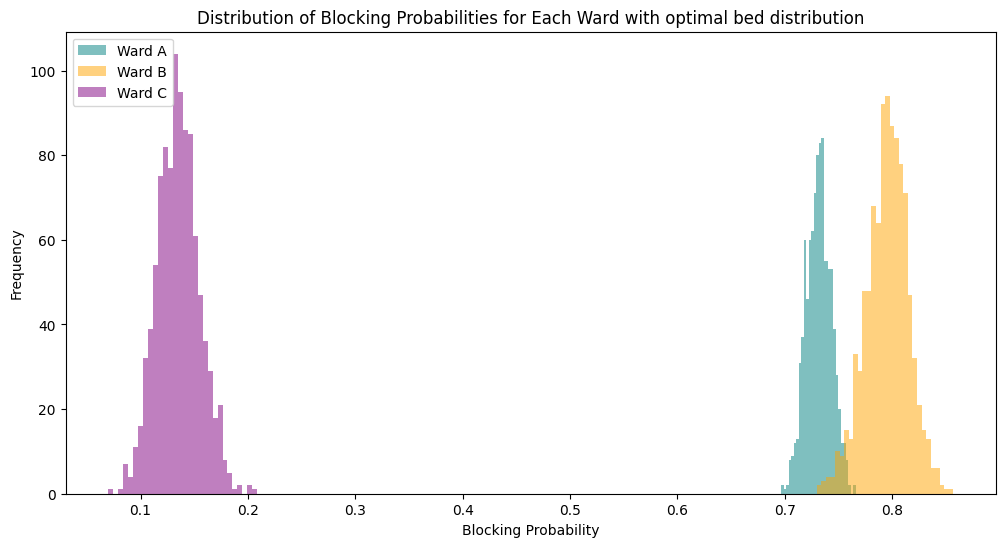

In [49]:
# visualize the distribution of blocking probabilities for each ward
plt.figure(figsize=(12, 6))
plt.hist(blocking_probabilities_A, bins=30, alpha=0.5, label='Ward A', color='teal')
plt.hist(blocking_probabilities_B, bins=30, alpha=0.5, label='Ward B', color='orange')
plt.hist(blocking_probabilities_C, bins=30, alpha=0.5, label='Ward C', color='purple')
plt.title('Distribution of Blocking Probabilities for Each Ward with optimal bed distribution')
plt.xlabel('Blocking Probability')
plt.ylabel('Frequency')
plt.legend()
plt.show()

In [50]:
exp_blocking_probabilities_A = []
exp_blocking_probabilities_B = []
exp_blocking_probabilities_C = []

for _ in range(runs):
    exponential_LOS_results = simulate_patient_flow((20, 10), simulation_days=365, 
    Ward_A_LOS=lambda: np.random.exponential(scale=4), 
    Ward_B_LOS=lambda: np.random.exponential(scale=6), 
    Ward_C_LOS=lambda: np.random.exponential(scale=5), total_beds=total_beds)

    exp_blocking_probabilities_A.append(exponential_LOS_results["blocking_probability"]["A"])
    exp_blocking_probabilities_B.append(exponential_LOS_results["blocking_probability"]["B"])
    exp_blocking_probabilities_C.append(exponential_LOS_results["blocking_probability"]["C"])

mean_exp_A = np.mean(exp_blocking_probabilities_A)
mean_exp_B = np.mean(exp_blocking_probabilities_B)
mean_exp_C = np.mean(exp_blocking_probabilities_C)

ci_exp_A = conf_interval(exp_blocking_probabilities_A)
ci_exp_B = conf_interval(exp_blocking_probabilities_B)
ci_exp_C = conf_interval(exp_blocking_probabilities_C)

print(f"Mean blocking probability for Ward A (Exponential LOS): {mean_exp_A:.4f}, 95% CI: {ci_exp_A}")
print(f"Mean blocking probability for Ward B (Exponential LOS): {mean_exp_B:.4f}, 95% CI: {ci_exp_B}")
print(f"Mean blocking probability for Ward C (Exponential LOS): {mean_exp_C:.4f}, 95% CI: {ci_exp_C}")

Mean blocking probability for Ward A (Exponential LOS): 0.3908, 95% CI: (np.float64(0.38981729255022823), np.float64(0.3917960652767435))
Mean blocking probability for Ward B (Exponential LOS): 0.1573, 95% CI: (np.float64(0.15539700221515867), np.float64(0.1591598810993421))
Mean blocking probability for Ward C (Exponential LOS): 0.0048, 95% CI: (np.float64(0.004620021237534523), np.float64(0.005055765977623856))


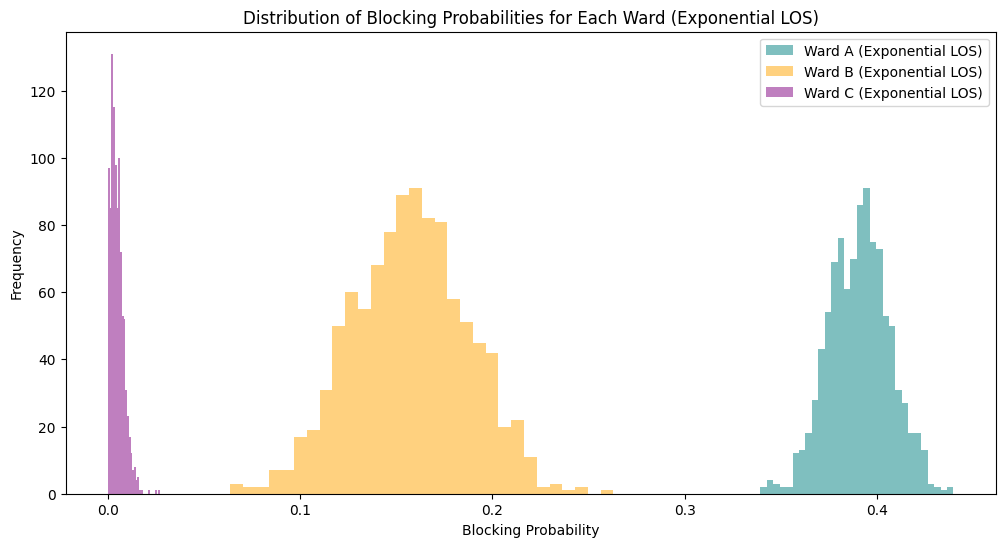

In [51]:
# visualize the results for exponential LOS

plt.figure(figsize=(12, 6))
plt.hist(exp_blocking_probabilities_A, bins=30, alpha=0.5, label='Ward A (Exponential LOS)', color='teal')
plt.hist(exp_blocking_probabilities_B, bins=30, alpha=0.5, label='Ward B (Exponential LOS)', color='orange')
plt.hist(exp_blocking_probabilities_C, bins=30, alpha=0.5, label='Ward C (Exponential LOS)', color='purple')
plt.title('Distribution of Blocking Probabilities for Each Ward (Exponential LOS)')
plt.xlabel('Blocking Probability')
plt.ylabel('Frequency')
plt.legend()
plt.show()

Ward A (Mean LOS = 4): KS Statistic = 0.3135, p-value = 0.0000
Ward B (Mean LOS = 6): KS Statistic = 0.3196, p-value = 0.0000
Ward C (Mean LOS = 5): KS Statistic = 0.3152, p-value = 0.0000


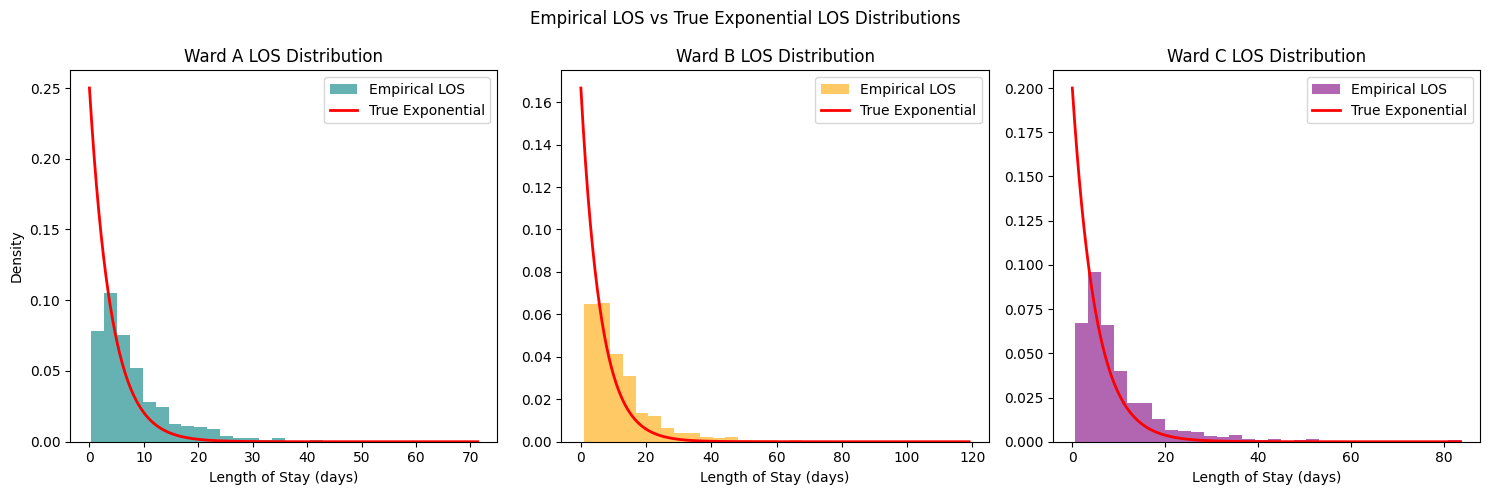

In [52]:
# Compare LOS samples to the true exponential distributions

los_samples_A = [Ward_A_LOS() for _ in range(1000)]
los_samples_B = [Ward_B_LOS() for _ in range(1000)]
los_samples_C = [Ward_C_LOS() for _ in range(1000)]

ks_stat_A, p_value_A = stats.kstest(los_samples_A, 'expon', args=(0, 4))
ks_stat_B, p_value_B = stats.kstest(los_samples_B, 'expon', args=(0, 6))
ks_stat_C, p_value_C = stats.kstest(los_samples_C, 'expon', args=(0, 5))

print(f"Ward A (Mean LOS = 4): KS Statistic = {ks_stat_A:.4f}, p-value = {p_value_A:.4f}")
print(f"Ward B (Mean LOS = 6): KS Statistic = {ks_stat_B:.4f}, p-value = {p_value_B:.4f}")
print(f"Ward C (Mean LOS = 5): KS Statistic = {ks_stat_C:.4f}, p-value = {p_value_C:.4f}")

# Visualise LOS distributions against the true exponential distributions

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Ward A
axes[0].hist(
    los_samples_A,
    bins=30,
    density=True,
    alpha=0.6,
    color='teal',
    label='Empirical LOS'
)

x_A = np.linspace(0, max(los_samples_A), 500)
axes[0].plot(
    x_A,
    stats.expon.pdf(x_A, loc=0, scale=4),
    'r-',
    lw=2,
    label='True Exponential'
)

axes[0].set_title('Ward A LOS Distribution')
axes[0].set_xlabel('Length of Stay (days)')
axes[0].set_ylabel('Density')
axes[0].legend()

# Ward B
axes[1].hist(
    los_samples_B,
    bins=30,
    density=True,
    alpha=0.6,
    color='orange',
    label='Empirical LOS'
)

x_B = np.linspace(0, max(los_samples_B), 500)
axes[1].plot(
    x_B,
    stats.expon.pdf(x_B, loc=0, scale=6),
    'r-',
    lw=2,
    label='True Exponential'
)

axes[1].set_title('Ward B LOS Distribution')
axes[1].set_xlabel('Length of Stay (days)')
axes[1].legend()

# Ward C
axes[2].hist(
    los_samples_C,
    bins=30,
    density=True,
    alpha=0.6,
    color='purple',
    label='Empirical LOS'
)

x_C = np.linspace(0, max(los_samples_C), 500)
axes[2].plot(
    x_C,
    stats.expon.pdf(x_C, loc=0, scale=5),
    'r-',
    lw=2,
    label='True Exponential'
)

axes[2].set_title('Ward C LOS Distribution')
axes[2].set_xlabel('Length of Stay (days)')
axes[2].legend()

plt.suptitle('Empirical LOS vs True Exponential LOS Distributions')
plt.tight_layout()
plt.show()

In [54]:
# Test which distribution (lognormal or exponential) results in the least number of rejections and ICU overflows
lognormal_rejections = results["rejected"]["Sum"]

print(f"Lognormal LOS: Total Rejections = {lognormal_rejections}, ICU Overflows = {results['overflow_B']}")
exponential_rejections = exponential_LOS_results["rejected"]["Sum"]
print(f"Exponential LOS: Total Rejections = {exponential_rejections}, ICU Overflows = {exponential_LOS_results['overflow_B']}")

Lognormal LOS: Total Rejections = 2310, ICU Overflows = 9
Exponential LOS: Total Rejections = 989, ICU Overflows = 9


In [93]:
np.random.seed(42)
total_beds_options = [60, 70, 75, 80, 100]
bed_distribution = (25, 10)  # Using the best distribution found earlier

print("Testing different total bed options:")
for beds in total_beds_options:
    results = simulate_patient_flow(bed_distribution, simulation_days=365, Ward_A_LOS=Ward_A_LOS, 
    Ward_B_LOS=Ward_B_LOS, Ward_C_LOS=Ward_C_LOS, total_beds=beds)
    
    print(f"Total Beds: {beds}, Admissions: {results['admitted']}, Rejections: {results['rejected']}, ICU Overflows: {results['overflow_B']}, Sum of Rejections: {results['rejected']['Sum']}")



Testing different total bed options:
Total Beds: 60, Admissions: {'A': 987, 'B': 256, 'C': 905}, Rejections: {'A': 1188, 'B': 188, 'C': 1227, 'Sum': 2603}, ICU Overflows: 11, Sum of Rejections: 2603
Total Beds: 70, Admissions: {'A': 933, 'B': 256, 'C': 1168}, Rejections: {'A': 1273, 'B': 203, 'C': 996, 'Sum': 2472}, ICU Overflows: 7, Sum of Rejections: 2472
Total Beds: 75, Admissions: {'A': 983, 'B': 234, 'C': 1341}, Rejections: {'A': 1238, 'B': 251, 'C': 856, 'Sum': 2345}, ICU Overflows: 4, Sum of Rejections: 2345
Total Beds: 80, Admissions: {'A': 1015, 'B': 255, 'C': 1531}, Rejections: {'A': 1187, 'B': 160, 'C': 629, 'Sum': 1976}, ICU Overflows: 11, Sum of Rejections: 1976
Total Beds: 100, Admissions: {'A': 940, 'B': 245, 'C': 2058}, Rejections: {'A': 1254, 'B': 186, 'C': 168, 'Sum': 1608}, ICU Overflows: 7, Sum of Rejections: 1608


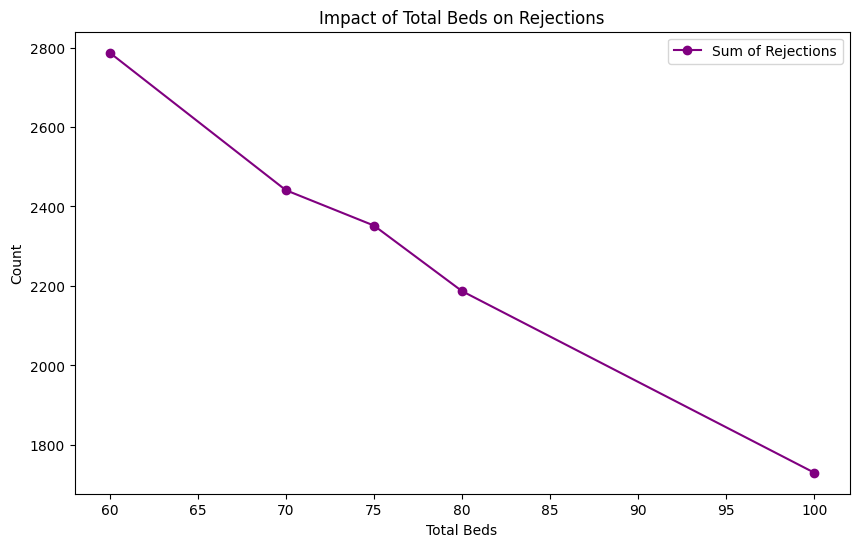

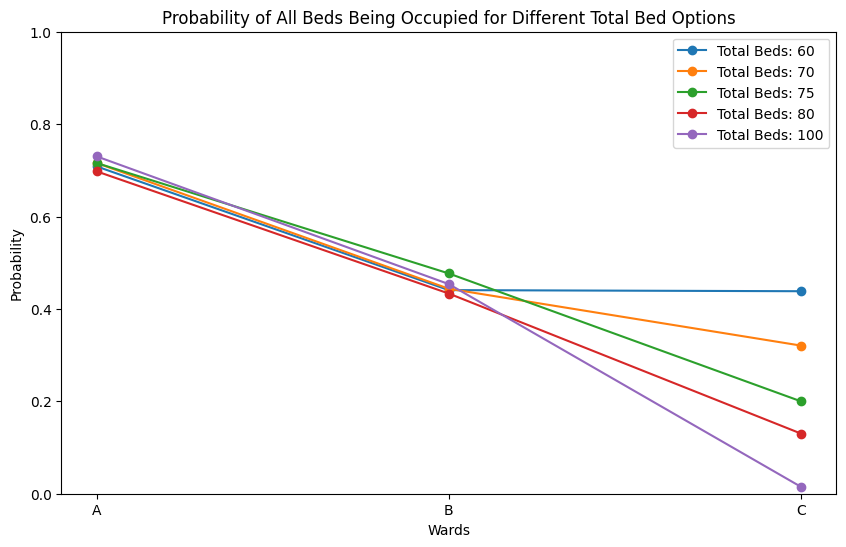

In [81]:
# Visualise the distribution of beds for sum of rejections and ICU overflows for different total bed options

plt.figure(figsize=(10, 6))
plt.plot(total_beds_options, [simulate_patient_flow(bed_distribution, simulation_days=365, Ward_A_LOS=Ward_A_LOS, Ward_B_LOS=Ward_B_LOS, Ward_C_LOS=Ward_C_LOS, total_beds=beds)["rejected"]["Sum"] for beds in total_beds_options], marker='o', label='Sum of Rejections', color='purple')
plt.title('Impact of Total Beds on Rejections')
plt.xlabel('Total Beds')
plt.ylabel('Count')
plt.legend()
plt.show()

# Visualise probability of all beds being occupied for each ward for different total bed options
plt.figure(figsize=(10, 6))
for beds in total_beds_options:
    results = simulate_patient_flow(bed_distribution, simulation_days=365, Ward_A_LOS=Ward_A_LOS, 
    Ward_B_LOS=Ward_B_LOS, Ward_C_LOS=Ward_C_LOS, total_beds=beds)
    
    probabilities = [results['blocking_probability'][ward] for ward in wards]
    plt.plot(wards, probabilities, marker='o', label=f'Total Beds: {beds}')

plt.title('Probability of All Beds Being Occupied for Different Total Bed Options')
plt.xlabel('Wards')
plt.ylabel('Probability')
plt.ylim(0, 1)
plt.legend()
plt.show()